In [4]:
import evaluate
import torch
import matplotlib.pyplot as plt

# Exploring a compositional dataset 

This notebook, is for me to test my theories of what it means to be compositional. 

We start off with the assumption:

A compositional dataset is one that consists of unseen combinations of seen values.
Therefore can bedescribed as marginal distrubtions that cover the same values but shifted multivaraite distributions.

Lets start with a simple function $y=x_1 * x_2$

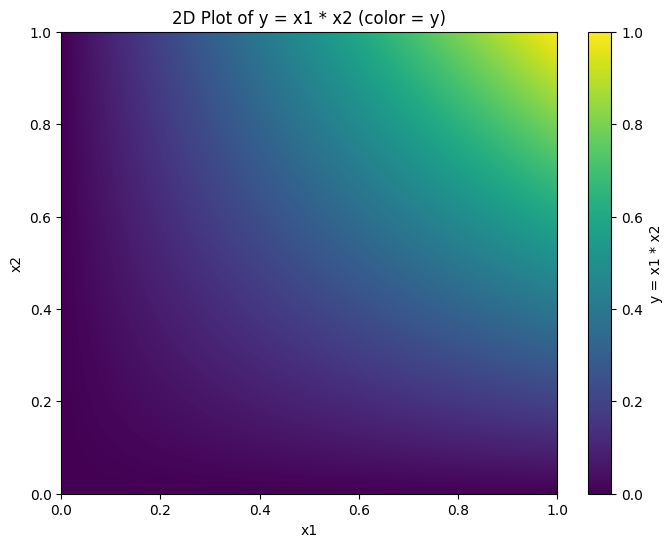

In [ ]:
# Create the data for y = x1 * x2
N = 1000
x1_vals = torch.linspace(0, 1, N)
x2_vals = torch.linspace(0, 1, N)

X, Y = torch.meshgrid(x1_vals, x2_vals, indexing="ij")
Z = X * Y  # y = x1 * x2

# 2D plot with color as the third dimension
plt.figure(figsize=(8, 6))
plt.imshow(
    Z.numpy(),
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="viridis",
    aspect="auto"
)

plt.colorbar(label="y = x1 * x2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Plot of y = x1 * x2 (color = y)")
plt.show()


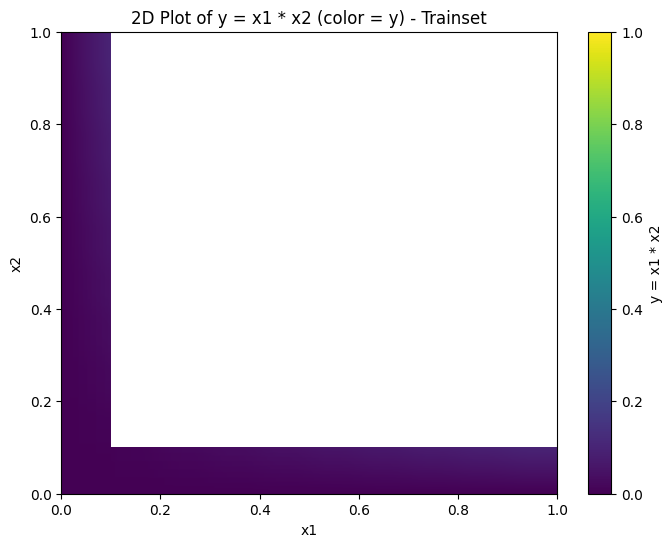

In [29]:
# Trainset:
# box 1
x1_train_b1_vals = torch.linspace(0, 1, N)
x2_train_b1_vals = torch.linspace(0, 0.1, 10)
X_train_b1, Y_train_b1 = torch.meshgrid(x1_train_b1_vals, x2_train_b1_vals, indexing="ij")
Z_train_b1 = X_train_b1 * Y_train_b1

# box 2
x1_train_b2_vals = torch.linspace(0, 0.1, 10)
x2_train_b2_vals = torch.linspace(0, 1, N)
X_train_b2, Y_train_b2 = torch.meshgrid(x1_train_b2_vals, x2_train_b2_vals, indexing="ij")
Z_train_b2 = X_train_b2 * Y_train_b2


# 2D plot with color as the third dimension
# set max to 1

plt.figure(figsize=(8, 6))
plt.imshow(
    Z_train_b1.numpy(),
    origin="lower",
    extent=[0, 1, 0, 0.1],
    cmap="viridis",
    aspect="auto",
    vmax=1.0

)

plt.imshow(
    Z_train_b2.numpy(),
    origin="lower",
    extent=[0, 0.1, 0, 1],
    cmap="viridis",
    aspect="auto",
    vmax=1.0

)

plt.ylim(0.0, 1.0)
plt.xlim(0.0, 1.0)
plt.colorbar(label="y = x1 * x2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Plot of y = x1 * x2 (color = y) - Trainset")
plt.show()

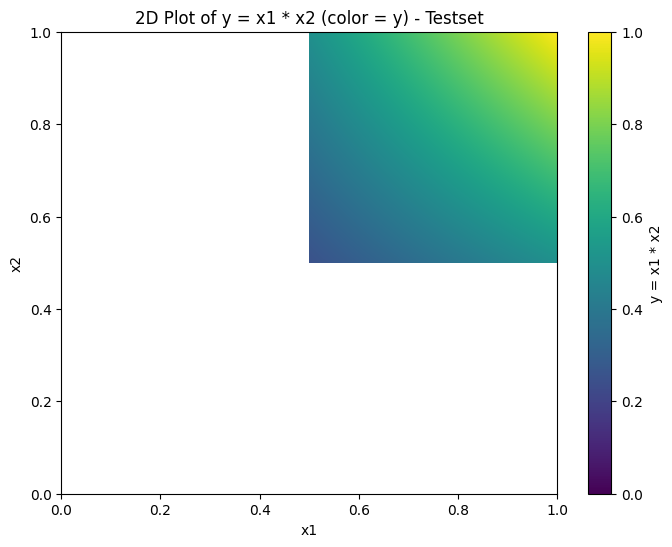

In [34]:
# Testset:
x1_test_vals = torch.linspace(0.5, 1, N)
x2_test_vals = torch.linspace(0.5, 1, N)
X_test, Y_test = torch.meshgrid(x1_test_vals, x2_test_vals, indexing="ij")
Z_test = X_test * Y_test
# 2D plot with color as the third dimension
# set max to 1

plt.figure(figsize=(8, 6))
plt.imshow(
    Z_test.numpy(),
    origin="lower",
    extent=[0.5, 1, 0.5, 1],
    cmap="viridis",
    aspect="auto",
    vmax=1.0, 
    vmin=0.0

)
plt.ylim(0.0, 1.0)
plt.xlim(0.0, 1.0)
plt.colorbar(label="y = x1 * x2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Plot of y = x1 * x2 (color = y) - Testset")
plt.show()

In [13]:
kl_divergence = evaluate.KLDivergenceMetric(None)

In [ ]:
# Marginals 

# x1

if x1_train_b1_vals.min() <= x1_test_vals.min() and x1_train_b1_vals.max() >= x1_test_vals.max():
    print("x1 train covers x1 test, values have been seen")


if x2_train_b2_vals.min() <= x2_test_vals.min() and x2_train_b2_vals.max() >= x2_test_vals.max():
    print("x2 train covers x2 test, values have been seen")


tensor(0.) tensor(1.)
tensor(0.5000) tensor(1.)
x1 train covers x1 test, values have been seen
tensor(0.) tensor(1.)
tensor(0.5000) tensor(1.)
x2 train covers x2 test, values have been seen


In [45]:
print(X_train_b1.flatten())
print(Y_train_b1.flatten())

tensor([0., 0., 0.,  ..., 1., 1., 1.])
tensor([0.0000, 0.0111, 0.0222,  ..., 0.0778, 0.0889, 0.1000])


In [50]:
train_multivarite = torch.stack([X_train_b1.flatten(), Y_train_b1.flatten()], dim=1)
test_multivarite = torch.stack([X_test.flatten(), Y_test.flatten()], dim=1)

kl_value = kl_divergence(test_multivarite, test_multivarite)
print("KL Divergence between train and test multivariate distributions:", kl_value)


KL Divergence between train and test multivariate distributions: -159.47328339083344
